In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import os
from matplotlib import pyplot as plt
# Set working directory
os.chdir("/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/")

# Verify
print("Current working directory:", os.getcwd())

import sys
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from torch_geometric.data import Data

from torch_geometric.data import Dataset, Data
from torch.utils.data import DataLoader
# from torch_geometric.loader import DataLoader
import argparse
from train_utility_sampling.train_utility import (
    split_graph_by_time,
    train_step,
    validation_step, 
    save_sampling_result,
    train_step_single_image,
    )

from utils.data.unstructure_dataset import (
    create_ns_dataset,
    )
from utils.data.unstructure_dataset import (
    GraphNavierStokes, 
    collate_graph_inr, 
    GraphSomaDataset, 
    GraphBurgers, 
    GraphNavierStokesSampling,
    get_graph_t_idx,
    )
# sys.path.append(str(Path(__file__).parents[1]))
# sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
from utils.load_inr import create_inr_instance, load_inr_model

from torchdiffeq import odeint
from torch_geometric.data import DataLoader as GDataLoader
import numpy as np
from train_utility_sampling.SamplerWrapper import (
    InrSamplerWrapper,
    graph_3d_cluster,
    graph_2d_cluster,
    add_cluster_label,
    sample_random_node_indices_per_cluster,
    INRSingle2dSamplerWrapper,
    graph_2d_cluster_single_image,
)
from mmap_ninja import RaggedMmap
from hydra import initialize, compose

# from train_utility_sampling.SamplerWrapper import InrSamplerWrapper, graph_3d_cluster, graph_2d_cluster, add_cluster_label, sample_random_node_indices_per_cluster
# from mmap_ninja import RaggedMmap
# from hydra import initialize, compose

# NS_inr_save_name = 'NS_keep_for_test_file'
# NS_inr_save_dir = '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/'
device = torch.device('cuda')

Current working directory: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


In [4]:
def load_inr(i, model_dir):
    inr_save_path = os.path.join(model_dir, f"{i}.pt")
    inr_results = torch.load(inr_save_path, weights_only=False)
    cfg = inr_results['cfg']

    # create & load weights
    torch.set_default_dtype(torch.float32)
    inr = create_inr_instance(cfg, input_dim=2, output_dim=1, device=device)
    inr.load_state_dict(inr_results["inr"])
    inr.to(device).eval()
    return inr 

def grad_coor(grad1, grad2):
    return torch.dot(grad1, grad2)/torch.norm(grad1)/torch.norm(grad2)

def loss_function(features_recon, features):
    loss = features_recon
    loss = ((features_recon - features)**2)
    return loss

In [4]:
# one best full run '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/2025-08-14-12-28-58NS1024_single_null_0.0001_lr_5e-4_depth_12_end_128_t100'
model_dir= '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/2025-08-14-12-28-58NS1024_single_null_0.0001_lr_5e-4_depth_12_end_128_t100'
model_path = os.path.join(model_dir, '0.pt')
save_results = torch.load(model_path, weights_only = False, map_location=device)

In [5]:
files = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(files)

['190.pt', '250.pt', '760.pt', '100.pt', '360.pt', '60.pt', '920.pt', '640.pt', '40.pt', '20.pt', '240.pt', '80.pt', '170.pt', '380.pt', '1250.pt', '840.pt', '460.pt', '570.pt', '430.pt', '0.pt', '70.pt', '110.pt', '1590.pt', '1580.pt', '450.pt', '1100.pt', '160.pt', '50.pt', '120.pt', '320.pt', '310.pt', '130.pt', '140.pt', '440.pt', '270.pt', '150.pt', '1110.pt', '30.pt', '370.pt', '90.pt', '10.pt', '960.pt', '740.pt', '230.pt', '1230.pt', '1370.pt', '200.pt']


In [8]:
allocated_gb = torch.cuda.memory_allocated() / (1024 ** 3)
print(f"Memory allocated: {allocated_gb:.2f} GB")

Memory allocated: 0.00 GB


In [9]:
def grad_norm_per_pixel(model, per_pix_losses, optimizer):
    pix_norms = []
    all_pix_grads = []
    losses = per_pix_losses.view(-1)
    len_losses = len(losses)

    for i, pix_loss in enumerate(losses):
        pix_grads = []
        optimizer.zero_grad()
        pix_loss.backward(retain_graph=True)
        for param in model.parameters():
            if param.grad is not None:
                pix_grads.append(param.grad.detach().view(-1))
        concat_grads = torch.cat(pix_grads)
        all_pix_grads.append(concat_grads)
        final_pix_norm = torch.norm(concat_grads)
        pix_norms.append(final_pix_norm.item())

    return pix_norms, all_pix_grads

In [27]:
torch.cuda.empty_cache()
graph = graph.to(device)
H = graph.cor.max().item()+1

features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)

rate = 1

center = (341, 341)

features = features[::rate, ::rate]
coords = coords[::rate, ::rate]

size = 30
for t in [10]:
    inr = load_inr(t, model_dir)
    inr.to(device)
    reconfeature = inr(coords)

    params = list(inr.parameters())
    per_pix_losses = loss_function(reconfeature, features)
    
    all_pix_grads = []

    for i in range(center[0]-size, center[0]+size):
        for j in range(center[1]-size, center[1]+size):
            loss = per_pix_losses[i, j]
            point_grad = torch.autograd.grad(
                loss, params, retain_graph=True, allow_unused=True
            )
            grads_all = [g.view(-1) for g in point_grad if g is not None]
            grad_vec = torch.cat(grads_all)
            all_pix_grads.append(grad_vec)

    batch_grad = torch.stack(all_pix_grads)
    cidx = size*(2*size)-size
    sel_grad = all_pix_grads[cidx]
    cor_tensor = torch.matmul(sel_grad, batch_grad.T).abs()/torch.norm(sel_grad)/torch.norm(batch_grad, dim=1)
    cor_array = cor_tensor.cpu().numpy().reshape(2*size, 2*size)
    np.save(f'center{center[0]}_{center[1]}_size{size}_i{t}',cor_array)
# batch_grad = torch.stack(all_pix_grads, device = torch.device('cpu'))
# batch_grad.shape

In [22]:
batch_grad = torch.stack(all_pix_grads)
batch_grad.shape
cidx = size*(2*size)-size
sel_grad = all_pix_grads[cidx]

cor_tensor = torch.matmul(sel_grad, batch_grad.T).abs()/torch.norm(sel_grad)/torch.norm(batch_grad, dim=1)

cor_array = cor_tensor.cpu().numpy().reshape(2*size, 2*size)
np.save(f'center{center[0]}_{center[1]}_size{size}_i{t}',cor_array)

In [33]:
cor_tensor2 = cor_tensor.clone()

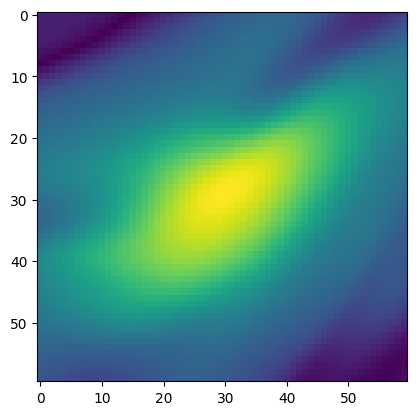

In [26]:
plt.imshow(cor_tensor.cpu().reshape(2*size, 2*size), vmin=0)

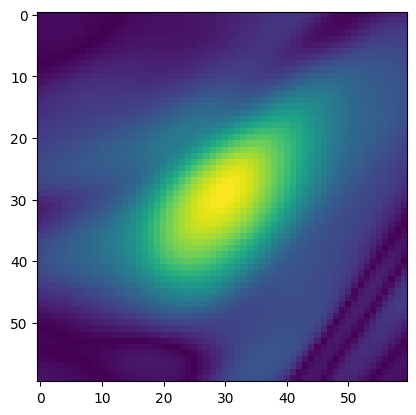

In [24]:
plt.imshow(cor_tensor.cpu().reshape(2*size, 2*size), vmin=0)

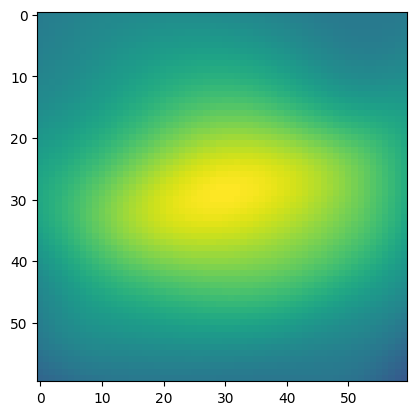

In [18]:
plt.imshow(cor_tensor.cpu().reshape(2*size, 2*size), vmin=0)

In [ ]:
torch.cuda.empty_cache()
graph = graph.to(device)
H = graph.cor.max().item()+1

features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)

rate = 1

center = (341, 341)

features = features[::rate, ::rate]
coords = coords[::rate, ::rate]

for i in [10]:
    inr = load_inr(i, model_dir)
    inr.to(device)
    reconfeature = inr(coords)

    params = list(inr.parameters())
    per_pix_losses = loss_function(reconfeature, features)
    
    all_pix_grads = []

    for i in range(1024//rate):
        for j in range(1024//rate):
            loss = per_pix_losses[i, j]
            point_grad = torch.autograd.grad(
                loss, params, retain_graph=True, allow_unused=True
            )
            grads_all = [g.view(-1) for g in point_grad if g is not None]
            grad_vec = torch.cat(grads_all)
            all_pix_grads.append(grad_vec)
batch_grad = torch.stack(all_pix_grads, device = torch.device('cpu'))
batch_grad.shape

TypeError: stack() got an unexpected keyword argument 'device'

In [ ]:
r_list = [1024//rate//3*(i+1) for i in range(2)]
cor_tensor = torch.empty((4, batch_grad.shape[0]))
k = 0
centers = []
for i in r_list:
    for j in r_list:
        sel_grad = all_pix_grads[i*1024//rate+j].cpu()

        cor_tensor[k] = torch.matmul(sel_grad, batch_grad.T).abs()/torch.norm(sel_grad)/torch.norm(batch_grad, dim=1)
        centers.append((i, j))
        k+=1
        
        

tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)
tensor(1.0000)


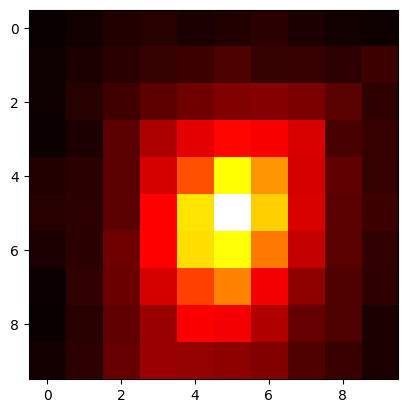

In [168]:
center_img3 = torch.zeros((1024//rate, 1024//rate))
for i in range(9):
    line_tensor = cor_tensor[i]
    img = line_tensor.reshape(1024//rate, 1024//rate)
    print(img.max())
    center_img3 += torch.roll(img, shifts=(1024//rate//2-centers[i][0], 1024//rate//2-centers[i][1]), dims = (0, 1))
center = 1024//rate//2
show = 5
plt.imshow(center_img3[center-show:center+show, center-show:center+show], cmap='hot', interpolation='nearest')

In [7]:
from train_utility_sampling.metalearning_sampling import (
    psnr,
    calculate_ssim,
    single_image_step,
)

In [32]:
graph = graph.to(device)
H = graph.cor.max().item()+1
is_train = False
features = graph.feat.view(H, H, 1)
coords = graph.space_emb.detach().view(H, H, 2)
model_dir ='/pscratch/sd/g/gzhao27/INR/SOMA/results/inr_sampling/2025-08-14-12-28-58NS1024_single_null_0.0001_lr_5e-4_depth_12_end_128_t100'
inr = load_inr(1590, model_dir)

features_recon = inr(coords)
if not is_train:
    with torch.no_grad():
        features_recon = inr(coords)
else:
    features_recon = inr(coords)

if is_train and cfg.sampling.type == "EVOS":
    # print("===p recon===\n" + str(features_recon) + "\n===p features ===\n" + str(features) + "\n===step===\n" + str(step))
    # loss = sampler._sampler_compute_loss(features_recon, features, step)
    sampler._sampler_compute_loss(features_recon, features, step)
# else:
    # loss = ((features_recon - graph.feat)**2).mean()
    # if not is_train:
        # print("---features recon---\n" + str(features_recon.shape))
        # print("---gt features---\n" + str(graph.feat.shape))
# loss = F.mse_loss(features_recon, graph.feat)

# Calculate PSNR and SSIM when return_reconstructions is True
psnr_score = None
ssim_score = None

max_val = features.max() - features.min()

psnr_score = psnr(features_recon, features)
ssim_score = calculate_ssim(features_recon.squeeze(), features.squeeze())
# print(psnr_score)

output = single_image_step(
    inr, 
    graph, 
    20, 
    is_train=False,
    return_reconstructions=True,
    relative
)

# img1 = features.squeeze().cpu()
# with torch.no_grad():
#     features_recon = inr(coords)
#     img2 = features_recon.detach().squeeze().cpu()

# import torch
# import math

# def calculate_psnr(img1, img2):
#     mse = torch.mean((img1 - img2) ** 2)
#     if mse == 0:
#         return float('inf')  # identical images
#     return 20 * math.log10(1.0 / math.sqrt(mse))  # assumes img range [0,1]

# # Example: both tensors are shape [C, H, W] and normalized to [0,1]
# psnr_value = calculate_psnr(img2, img1)
# print(f"PSNR: {psnr_value:.2f} dB")

# PSNR calculation

In [34]:
output

{'loss': tensor(0.0037, device='cuda:0'),
 'reconstructions': tensor([[-11.5623, -11.6527, -11.7642,  ..., -11.4302, -11.4449, -11.4393],
         [-11.5059, -11.5890, -11.6933,  ..., -11.4147, -11.4391, -11.4396],
         [-11.4548, -11.5302, -11.6265,  ..., -11.3931, -11.4287, -11.4362],
         ...,
         [-11.6463, -11.8033, -11.9623,  ..., -11.5323, -11.5486, -11.5534],
         [-11.5749, -11.7220, -11.8707,  ..., -11.5058, -11.5174, -11.5141],
         [-11.5032, -11.6406, -11.7787,  ..., -11.4786, -11.4864, -11.4755]],
        device='cuda:0'),
 'rel_loss': None,
 'psnr': np.float32(53.916916),
 'ssim': np.float64(0.9983493904361165)}

In [16]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def calculate_ssim(img1, img2):
    # Convert to HxWxC and uint8 if needed
    img1_np = np.transpose(img1, (1, 0))
    img2_np = np.transpose(img2, (1, 0))
    return ssim(img1_np, img2_np, channel_axis=0, data_range=1.0)  # range=1.0 for normalized images

ssim_value = calculate_ssim(img2, img1)
print(f"SSIM: {ssim_value:.4f}")

SSIM: 0.9841


In [16]:
tempcor

tensor(0.8901)

### draw image qualititive illustration

In [124]:
def sample_multiple_from_intervals(bounds, n_samples, device='cuda'):
    """
    Sample multiple integers from each interval.
    
    Args:
        bounds: tensor of shape (n_intervals, 2)
        n_samples: number of samples per interval
        device: device to run on
    
    Returns:
        tensor of shape (n_intervals, n_samples)
    """
    bounds = bounds.to(device)
    n_intervals = len(bounds)
    
    # Expand bounds for vectorized sampling
    low = bounds[:, 0].unsqueeze(1).expand(n_intervals, n_samples)
    high = bounds[:, 1].unsqueeze(1).expand(n_intervals, n_samples)
    
    rand_vals = torch.rand(n_intervals, n_samples, device=device)
    samples = low + torch.floor(rand_vals * (high - low + 1)).long()
    
    return samples

def generate_equal_bins(low, high, n_bins, device='cuda'):
    """
    Generate bin bounds with similar widths (max difference = 1).
    
    Args:
        low: lower bound of the range
        high: upper bound of the range (inclusive)
        n_bins: number of bins to create
        device: device to run on
    
    Returns:
        tensor of shape (n_bins, 2) containing [start, end] for each bin
    """
    device = torch.device(device)
    
    # Total range (inclusive)
    total_range = high - low + 1
    
    # Base width for each bin
    base_width = total_range // n_bins
    
    # Number of bins that need one extra element
    remainder = total_range % n_bins
    
    # Create bin bounds
    bounds = torch.zeros(n_bins, 2, dtype=torch.long, device=device)
    
    current_pos = low
    for i in range(n_bins):
        # First 'remainder' bins get base_width + 1, others get base_width
        width = base_width + (1 if i < remainder else 0)
        
        bounds[i, 0] = current_pos  # start of bin
        bounds[i, 1] = current_pos + width - 1  # end of bin (inclusive)
        
        current_pos += width
    
    return bounds

In [130]:
bounds

tensor([[   0,  511],
        [ 512, 1023]])

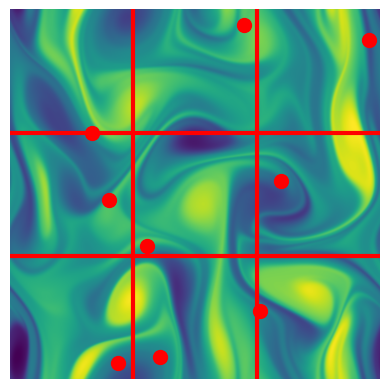

In [174]:

plt.imshow(graph.feat.cpu().numpy().reshape(1024, 1024))
plt.axis('off')
n_bins = 3


bounds = generate_equal_bins(0, 1024-1, n_bins, device='cpu')  # Example usage on CPU
cor = sample_multiple_from_intervals(bounds, n_bins*2, device='cpu')  # Example usage on CPU
cor1 = cor[:, :n_bins]
cor2 = cor[:, n_bins:].T

grid_positions = [1024//n_bins*i for i in range(1, n_bins)]
for x in grid_positions:
    plt.axvline(x=x + 0.5, color='r', linewidth=3)
    plt.axhline(y=x + 0.5, color='r', linewidth=3)
    
    
plt.scatter(cor1.flatten(), cor2.flatten(), color='red', s= 100)
    

# count = 0
# for i in range(len(grid_positions) - 1):
#     for j in range(len(grid_positions) - 1):
#         # centre of the cell in pixel coordinates
#         x_center = (grid_positions[j] + grid_positions[j+1]) / 2 - 0.5
#         y_center = (grid_positions[i] + grid_positions[i+1]) / 2 - 0.5
#         plt.text(x_center, y_center, str(count),
#                  ha='center', va='center',
#                  color='blue', fontsize=12)
# plt.figure(figsize=(10, 5))
# plt.imshow(features_recon.cpu().detach().numpy(), cmap='jet')

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

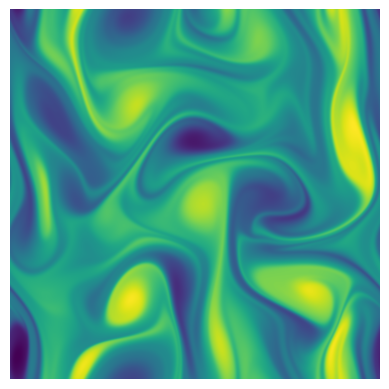

In [176]:
plt.imshow(graph.feat.cpu().numpy().reshape(1024, 1024))
plt.axis('off')

In [141]:
cor1.flatten()

tensor([497, 341, 689, 513])

In [139]:
cor1

tensor([[497, 341],
        [689, 513]])

In [140]:
cor2

tensor([[271, 819],
        [ 15, 697]])

In [138]:
cor

tensor([[497, 341, 271,  15],
        [689, 513, 819, 697]])

In [131]:
num_count = torch.zeros(1024)
for _ in range(100000):
    cor = sample_multiple_from_intervals(bounds, n_bins*2, device='cpu')
    tempcount = torch.bincount(cor.flatten())
    num_count[:len(tempcount)] += tempcount



In [134]:
num_count[500:600]

tensor([778., 795., 743., 808., 738., 812., 789., 800., 767., 738., 823., 768.,
        772., 787., 777., 725., 736., 765., 770., 745., 729., 759., 807., 770.,
        788., 741., 807., 825., 785., 781., 823., 725., 720., 791., 812., 753.,
        774., 750., 833., 803., 786., 796., 813., 755., 813., 806., 790., 782.,
        775., 799., 780., 778., 734., 736., 798., 773., 760., 795., 766., 784.,
        792., 767., 764., 727., 743., 790., 782., 808., 753., 803., 800., 826.,
        782., 735., 800., 773., 786., 768., 751., 761., 824., 828., 763., 805.,
        764., 786., 766., 825., 789., 761., 774., 772., 845., 739., 777., 786.,
        799., 813., 756., 792.])

(array([2., 3., 2., 1., 2., 2., 1., 2., 3., 2.]),
 array([100. , 178.7, 257.4, 336.1, 414.8, 493.5, 572.2, 650.9, 729.6,
        808.3, 887. ]),
 <BarContainer object of 10 artists>)

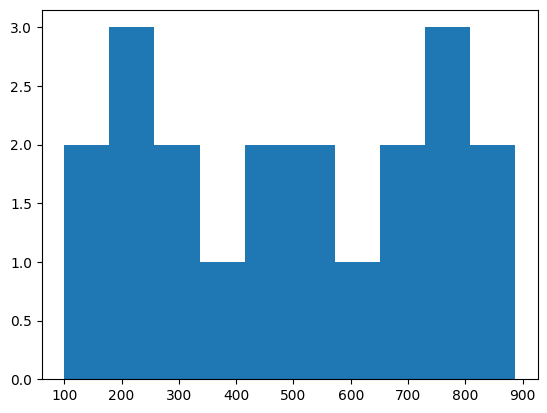

In [101]:
plt.hist(cor.flatten())


In [33]:
cor1

tensor([[116,  29,  16,  48],
        [483, 349, 389, 445],
        [538, 667, 755, 762],
        [819, 940, 933, 907]])

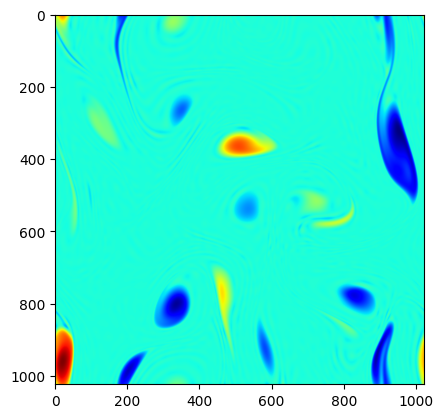

In [51]:
plt.imshow(features_recon.cpu().detach().numpy() - graph.feat.cpu().numpy().reshape(1024, 1024), cmap='jet')

In [14]:
from Run_Test import *

ModuleNotFoundError: No module named 'coralsoma'

In [ ]:
variables = test_inr_sample('3d_cluster')

In [42]:
variables = test_single_image_inr('2d_cluster')

test single image inr
loss: 0.610024631023407
rel loss: 1.0111850500106812


In [6]:
graph = variables['graph']
graph.cpu()

Data(time=[4096], cor=[4096, 2], feat=[4096, 1], space_emb=[4096, 2], T=1, cluster_set=[1], segments=[1])

In [56]:
graph_2d_cluster_single_image(graph, 100, compactness=0.1, cluster_type='slic')

In [57]:
graph.segments[0].max()

np.int64(118)

In [59]:
inr = variables['inr']

In [61]:
sum(p.numel() for p in inr.parameters() if p.requires_grad)

1185

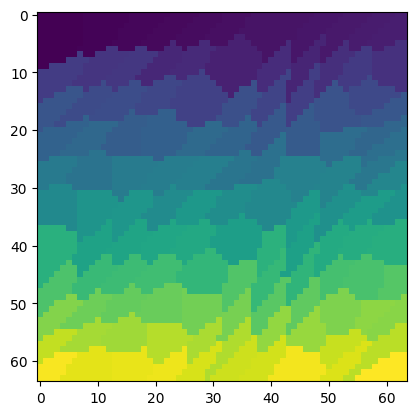

In [58]:
from matplotlib import pyplot as plt
plt.imshow(graph.segments[0])

In [12]:
import wandb
import pandas as pd

# Create API object
api = wandb.Api()

# Replace with your username/entity and project name
entity = "bnl-lemon"
project = "neurips-workshop-inr-sampling"

# Get all runs in the project
runs = api.runs(f"{entity}/{project}")

# Collect run data
time_list, config_list, name_list = [], [], []

for run in runs:
    if "5e-4" in run.name:
        continue

    if "NMT" in run.name:
        
    # # Summary metrics (final values)
    # summary_list.append(run.summary._json_dict)
    # # Config parameters
    # config_list.append({k: v for k, v in run.config.items() if not k.startswith('_')})
    # # Run name
    # name_list.append(run.name)

# Combine into a DataFrame
df = pd.DataFrame({
    "name": name_list,
    "config": config_list,
    "summary": summary_list
})

print(df.head())


                                                name  \
0  NS1024_single_NMT_0.001_lr_5e-4_depth_6_end_12...   
1  NS1024_single_random_0.001_lr_5e-4_depth_6_end...   
2  NS1024_single_2d_cluster_grid_0.001_lr_5e-4_de...   
3  NS1024_single_EVOS_0.001_lr_5e-4_depth_6_end_1...   
4  NS1024_single_NMT_0.001_lr_5e-4_depth_6_end_12...   

                                              config  \
0  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
1  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
2  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
3  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   
4  {'inr': {'w0': 30, 'depth': 6, 'loss_type': 'm...   

                                             summary  
0  {'Time': 170.77354645729065, '_runtime': 275.9...  
1  {'Time': 15.143675327301024, '_runtime': 101.6...  
2  {'Time': 22.89962124824524, '_runtime': 115.50...  
3  {'Time': 29.03055763244629, '_runtime': 101.60...  
4  {'Time': 170.41129446029663, '_runtime': 273.7..

In [21]:
run.history()

,Time,psnr,test_loss,train_rel_loss,ssim,_runtime,_timestamp,train_loss,_step,test_rel_loss
0,0.459452,17.549164,28.926556,0.974325,0.001904,4.730480,1.755282e+09,216.653687,10,0.976502
1,0.510752,17.758789,27.563484,0.965602,0.007296,4.933698,1.755282e+09,212.107574,20,0.953217
2,0.564223,17.962273,26.301836,0.957289,0.015429,5.135529,1.755282e+09,208.756653,30,0.931146
3,0.616634,18.153378,25.169538,0.948619,0.027493,5.337400,1.755282e+09,205.653229,40,0.910883
4,0.669557,18.348587,24.063263,0.940358,0.042426,5.539310,1.755282e+09,201.997498,50,0.890640
...,...,...,...,...,...,...,...,...,...,...
495,29.142110,33.573982,0.722462,0.149120,0.852598,101.856838,1.755283e+09,0.775498,4960,0.154324
496,29.184635,34.812206,0.543241,0.109165,0.873633,102.034710,1.755283e+09,0.405353,4970,0.133820
497,29.227265,35.717693,0.441005,0.098420,0.890755,102.212590,1.755283e+09,0.324557,4980,0.120572
498,29.270730,36.517002,0.366871,0.076177,0.902535,102.385773,1.755283e+09,0.211765,4990,0.109972
